# PhaseGuard
## Circuit cost can hide quantum order

This notebook maps the 1D ANNNI model. It compares clean ground states with noisy state preparation.

**Main claim:** a phase detector can lose order because of its circuit. That loss does not prove a thermodynamic phase change.

The noise maps use N=8 and target depolarization after every preparation CNOT. We compare a 254-CNOT exact loader with a 28-CNOT variational circuit. A separate clean map uses N=12. Line cuts compare N=8, 12, and 16.

This work has substantial AI assistance. All results below come from executed local simulations. No QPU result is claimed.


In [1]:
from pathlib import Path
import json, numpy as np
from IPython.display import display, Image, Markdown, Code
from phaseguard import ANNNI, reference, order, classify, attenuation, crossing
ROOT = Path.cwd()
summary = json.loads((ROOT/'data/summary.json').read_text())
display(Markdown('**Saved result:** ' + str(summary['N8_grid_shape']) + ' noisy grid; ' + str(summary['N12_grid_shape']) + ' clean grid.'))


**Saved result:** [21, 21] noisy grid; [41, 41] clean grid.

## 1. Hamiltonian and exact checks

H = −Σ ZiZi+1 + κ Σ ZiZi+2 − h Σ Xi, with periodic boundaries and J1=1.

The solver works in the exact even global-spin-flip sector. This prevents false fidelity peaks from numerical mixing of nearly degenerate even and odd states. At h=0 it uses the equal positive superposition of basis ground states. The multicritical point has a ground-state manifold, not a unique selected phase.

All implementation files are in this package. The code is imported below; the final section displays the full source. Use the commands in README.md to repeat all simulations.


In [2]:
checks = json.loads((ROOT/'data/validation.json').read_text())
density_checks = json.loads((ROOT/'data/density_validation.json').read_text())
assert checks['hamiltonian_max_error'] < 1e-10
assert max(r['matrix_max_error'] for r in density_checks) < 1e-9
print('Hamiltonian error:', checks['hamiltonian_max_error'])
print('PennyLane density-matrix error:', max(r['matrix_max_error'] for r in density_checks))
print('N=12 largest ground-state residual:', summary['N12_max_residual'])


Hamiltonian error: 7.105427357601002e-15
PennyLane density-matrix error: 2.414179967047403e-12
N=12 largest ground-state residual: 2.4114786285927544e-10


## 2. Symmetry-safe phase signals

We measure C(d), the site average of ⟨Zi Zi+d⟩. We use S(q)=Σd C(d) cos(qd)/N.

The normalized signals are F=[N S(0)−1]/(N−1) and A=[N S(π/2)−1]/(N/2−1). Both equal one in their perfect ordered limit and zero for uncorrelated Z measurements. Raw ⟨Z⟩ is not used.

Each size uses a threshold fixed at the exact Ising point κ=0, h=1. The larger signal sets the ordered label. If neither signal passes the threshold, the label is weak order / para-like. The threshold is not fitted to the reference curves or noisy data.

Solid curves are the challenge Ising and upper KT references. The lower dashed curve is PT. These are qualitative finite-size references. We do not label an intermediate correlation momentum as a confirmed floating phase.


Fixed N=8 threshold: 0.5628839496768858
Fixed N=12 threshold: 0.5201176336115293


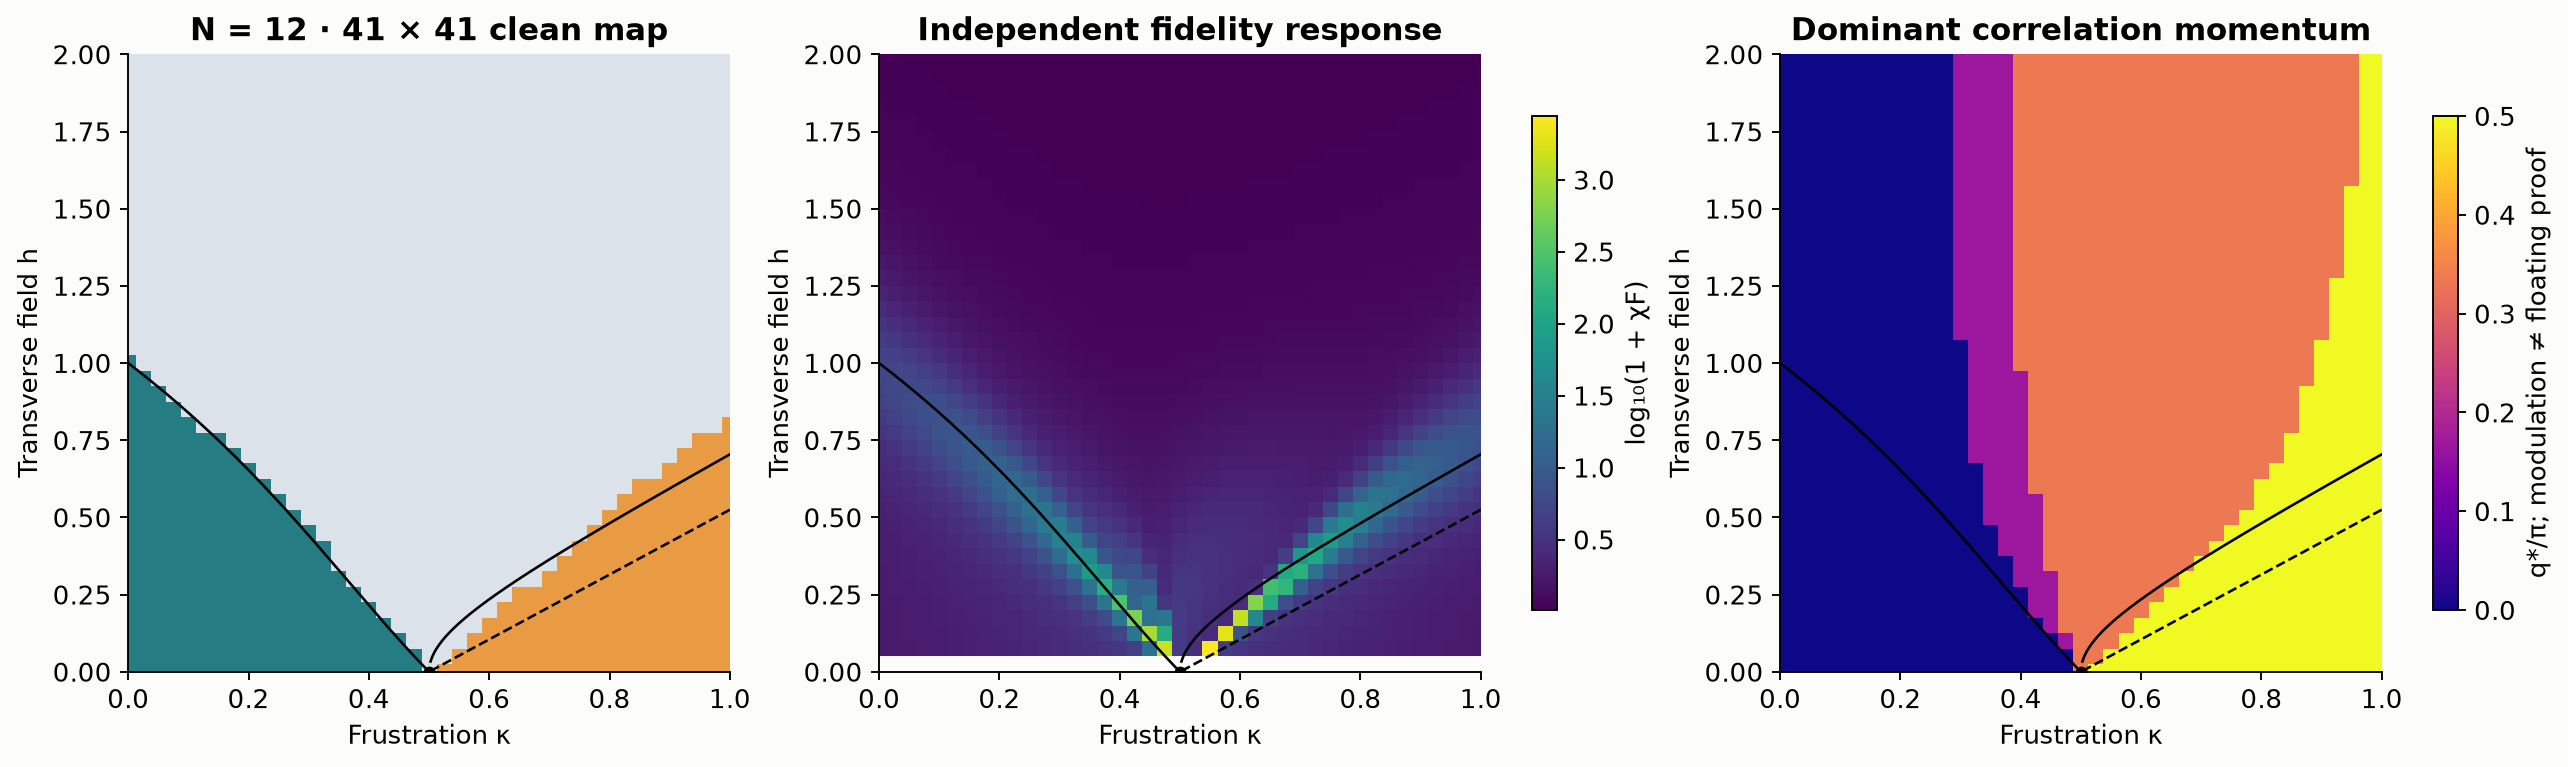

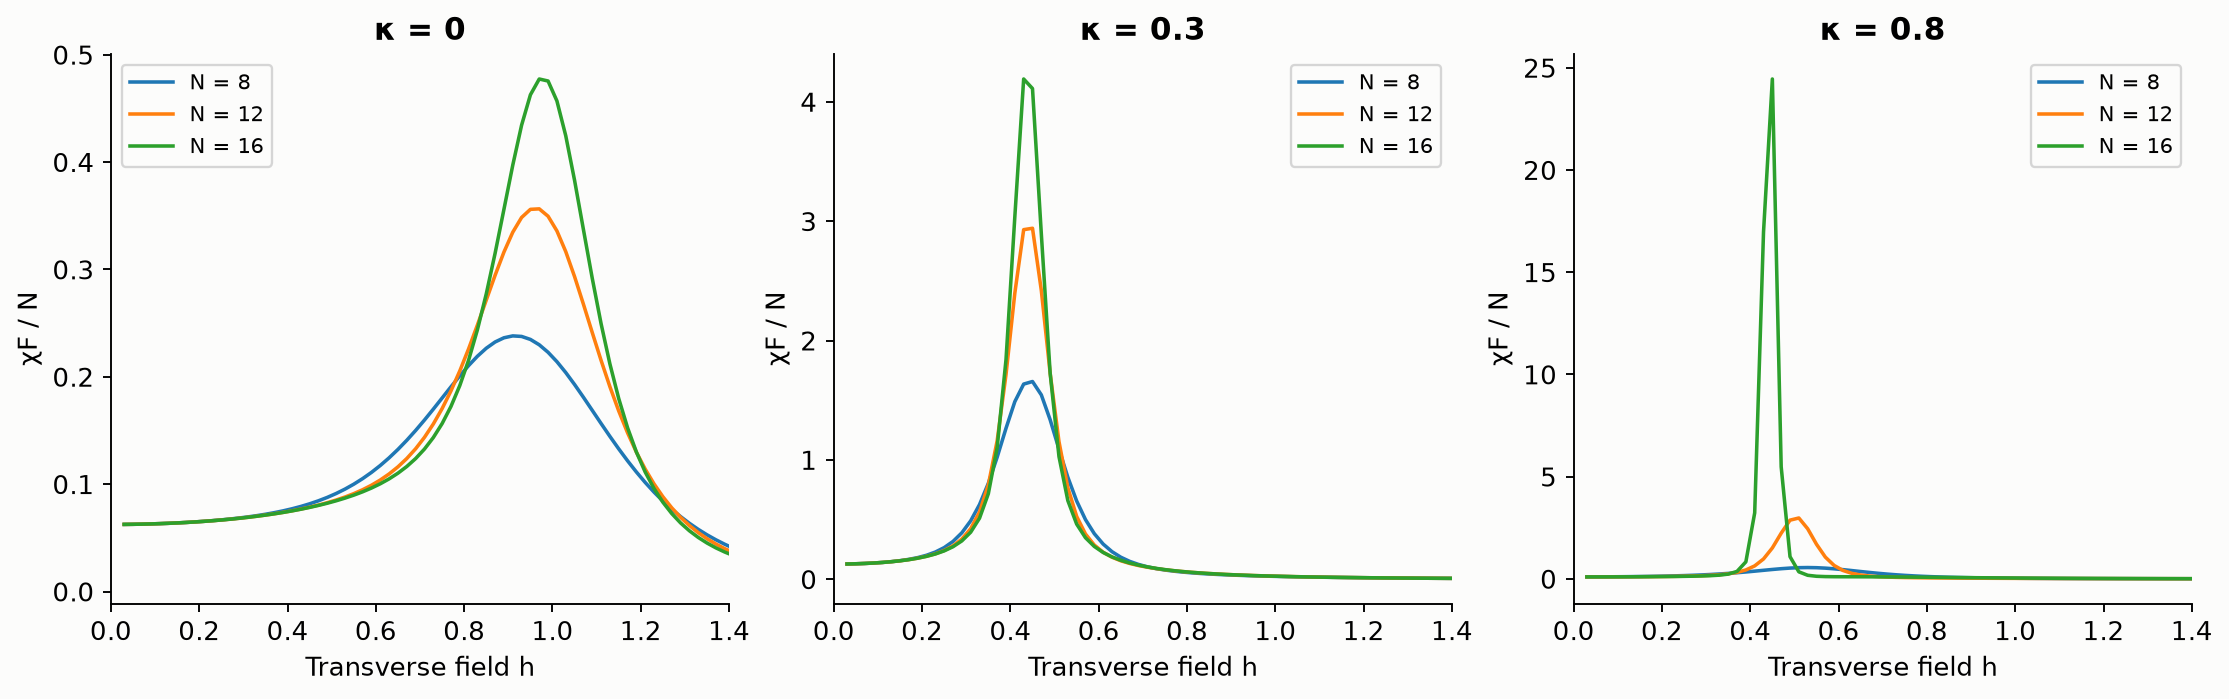

In [3]:
print('Fixed N=8 threshold:', summary['N8_threshold'])
print('Fixed N=12 threshold:', summary['N12_threshold'])
display(Image(filename=str(ROOT/'figures/clean_N12_diagnostics.png')))
display(Image(filename=str(ROOT/'figures/finite_size.png')))


## 3. Actual gate noise in state preparation

For each N=8 ground state, PennyLane constructs a Möttönen circuit. The circuit starts in |0…0⟩. The main grid runs the full gate list. A depolarizing channel follows every CNOT on its target: unchanged with probability 1−p, and each X/Y/Z error with probability p/3.

One-qubit gates and final direct Z measurements are ideal. A fast exact density-matrix implementation applies the same PennyLane gate list. It is checked against `default.mixed`. The clean p=0 state is obtained from exact diagonalization after independent checks of the compiled clean circuit.

These are detected-order maps of noisy outputs. Weak order is not evidence that the Hamiltonian entered a different equilibrium phase.


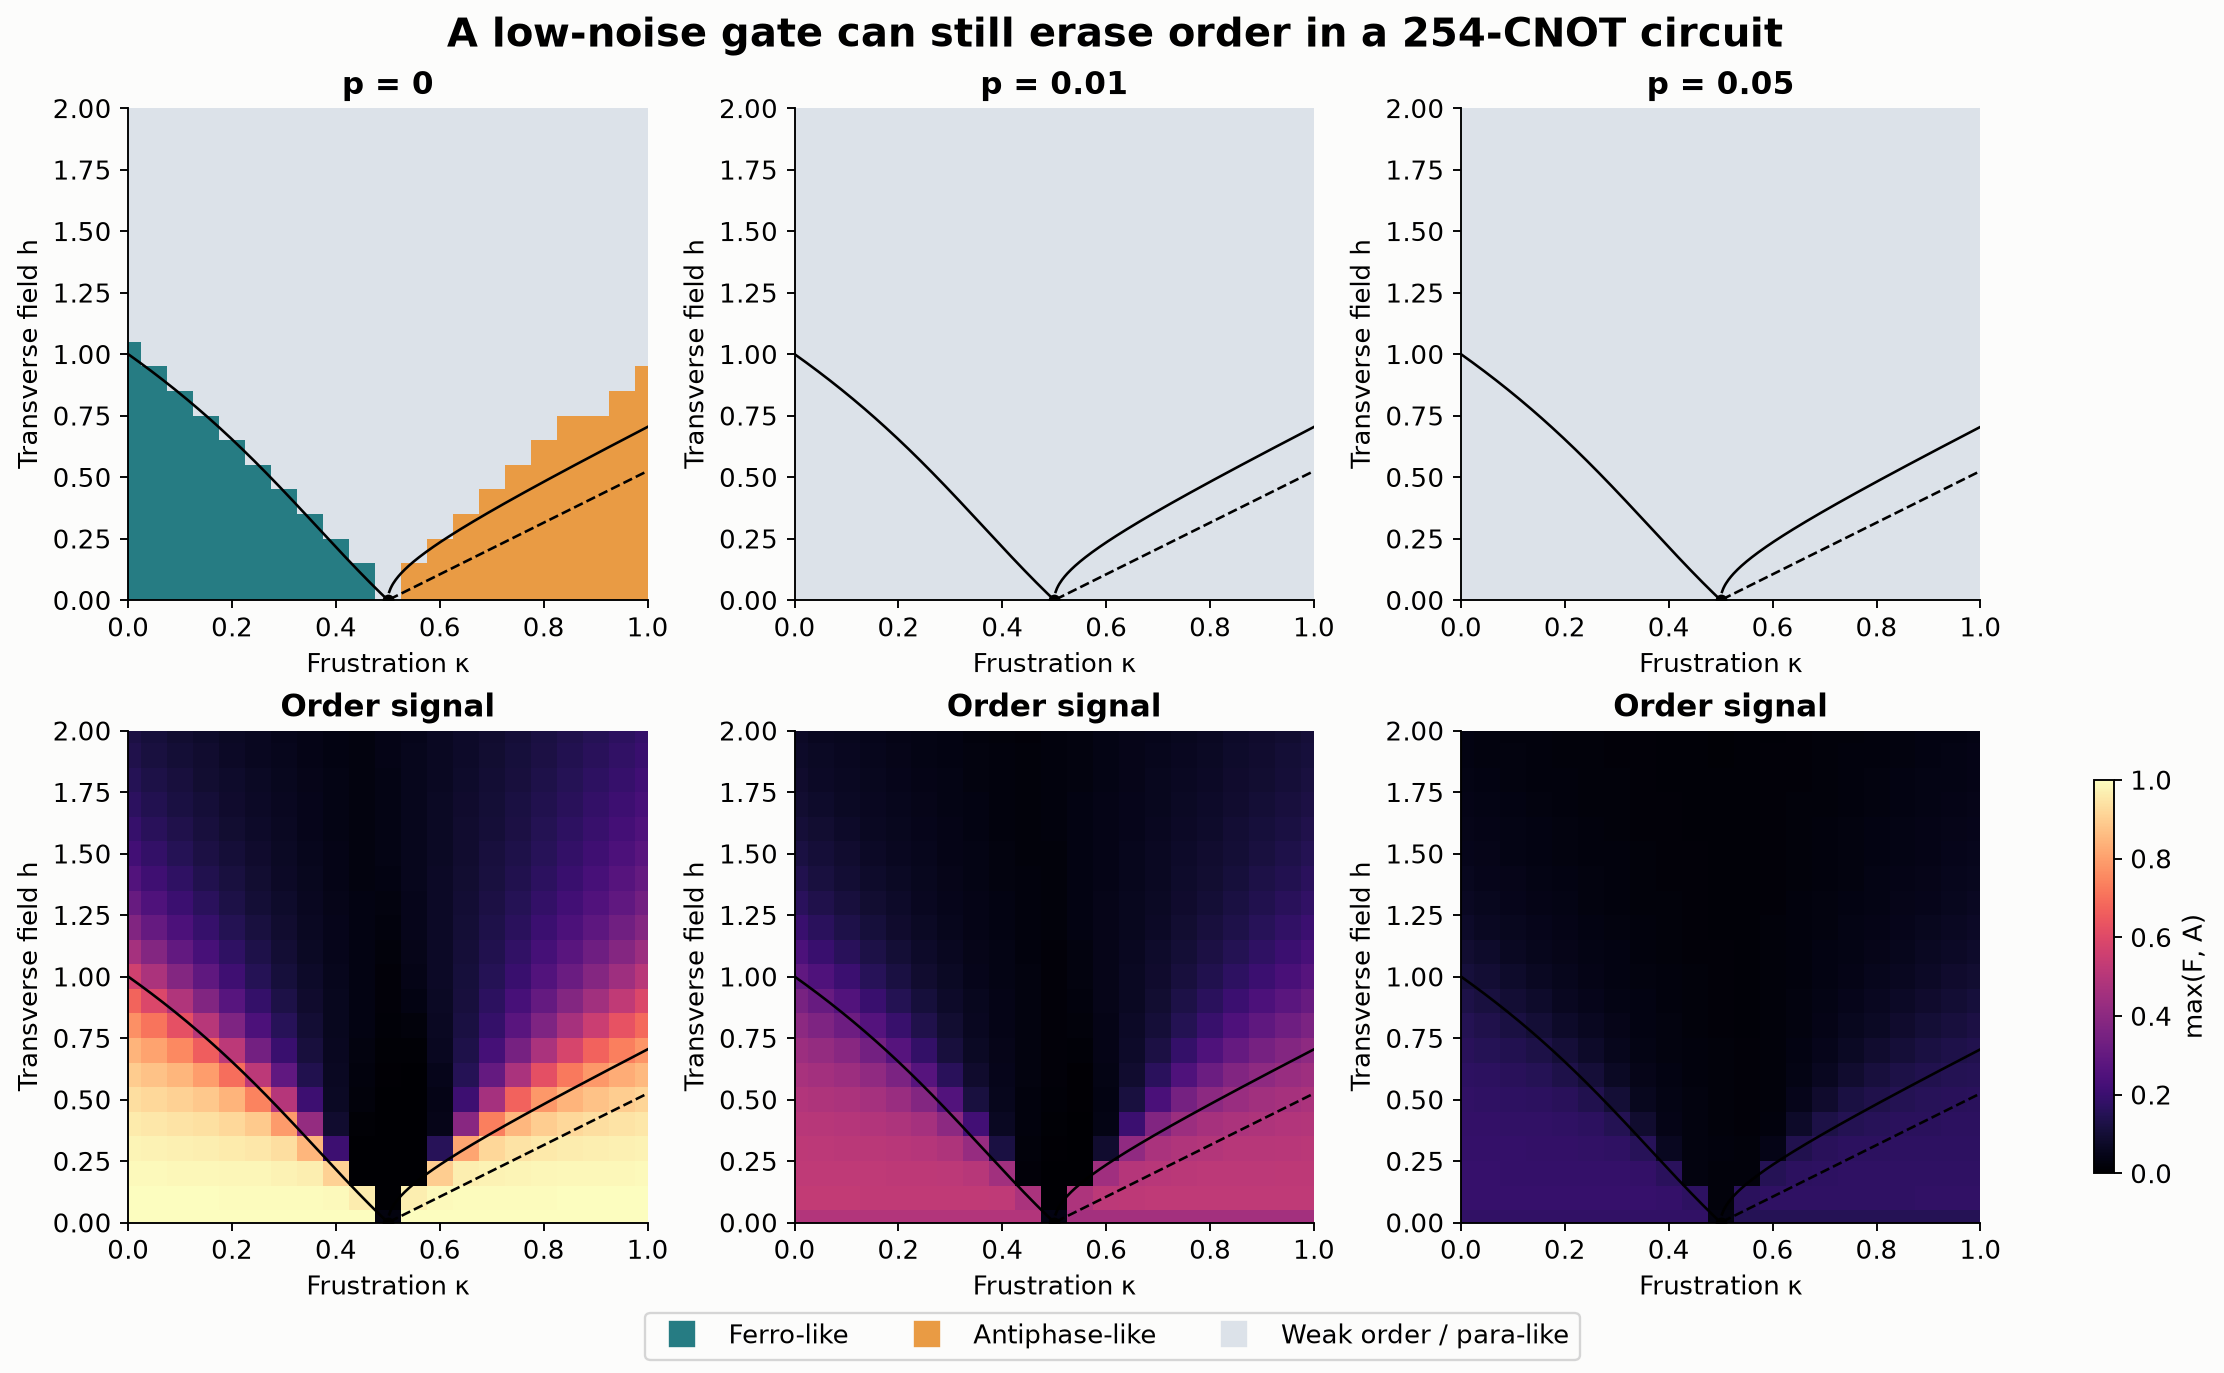

Preparation CNOT range: [254, 254]
[
  {
    "p": 0.01,
    "label_agreement_with_clean": 0.7120181405895691,
    "ferro_recall": 0.0,
    "anti_recall": 0.0,
    "correlation_MAE": 0.14234134290261435,
    "zne_label_agreement_with_clean": 0.9365079365079365,
    "zne_correlation_MAE": 0.09322576978536899,
    "mean_ground_state_fidelity": 0.1684820106884108,
    "mean_purity": 0.04057144962492496
  },
  {
    "p": 0.05,
    "label_agreement_with_clean": 0.7120181405895691,
    "ferro_recall": 0.0,
    "anti_recall": 0.0,
    "correlation_MAE": 0.24313332044920044,
    "zne_label_agreement_with_clean": 0.7120181405895691,
    "zne_correlation_MAE": 0.21504048686631386,
    "mean_ground_state_fidelity": 0.009628875988689651,
    "mean_purity": 0.006631481322003902
  }
]


In [4]:
display(Image(filename=str(ROOT/'figures/preparation_triptych.png')))
print('Preparation CNOT range:', summary['preparation_CNOT_range'])
print(json.dumps(summary['noise'], indent=2))


## 4. Boundary estimates and resolution

Boundary values use linear interpolation of the first downward threshold crossing. Grid spacing is Δh=0.1 for the noisy map. A missing boundary is reported as `None`. It means the selected order signal never passes the fixed threshold; it is not a measured transition at h=0.

The clean map has Δh=0.05. Line cuts have Δh=0.02. Finite-size and threshold error exceed interpolation precision near the narrow floating region.


In [5]:
print(json.dumps(summary['preparation_boundaries'], indent=2))
print('Threshold sensitivity:', summary['threshold_sensitivity'])
print('N=8 reference agreement outside the floating strip:',
      summary['reference_agreement_N8_clean_outside_floating_band'])


[
  {
    "kappa": 0,
    "p": 0.0,
    "boundary": 1.0000000000000007
  },
  {
    "kappa": 0,
    "p": 0.01,
    "boundary": null
  },
  {
    "kappa": 0,
    "p": 0.05,
    "boundary": null
  },
  {
    "kappa": 0.3,
    "p": 0.0,
    "boundary": 0.4774615523303055
  },
  {
    "kappa": 0.3,
    "p": 0.01,
    "boundary": null
  },
  {
    "kappa": 0.3,
    "p": 0.05,
    "boundary": null
  },
  {
    "kappa": 0.6,
    "p": 0.0,
    "boundary": 0.24473996113747432
  },
  {
    "kappa": 0.6,
    "p": 0.01,
    "boundary": null
  },
  {
    "kappa": 0.6,
    "p": 0.05,
    "boundary": null
  },
  {
    "kappa": 0.8,
    "p": 0.0,
    "boundary": 0.6381899379685467
  },
  {
    "kappa": 0.8,
    "p": 0.01,
    "boundary": null
  },
  {
    "kappa": 0.8,
    "p": 0.05,
    "boundary": null
  },
  {
    "kappa": 1.0,
    "p": 0.0,
    "boundary": 0.9317567478105139
  },
  {
    "kappa": 1.0,
    "p": 0.01,
    "boundary": null
  },
  {
    "kappa": 1.0,
    "p": 0.05,
    "boundary": nul

## Short-circuit and finite-shot controls

Four layers of RY rotations and nearest-neighbor CNOTs use 28 CNOTs. Clean optimization uses energy plus 0.5(1−⟨X⊗N⟩). The symmetry penalty does not use target-state fidelity. The same clean parameters are used at each noise strength. All parameters and optimizer outcomes are saved in `variational_control/`.

The finite-shot check draws complete Z bitstrings. Every pair estimate uses the same batch, so the simulation retains covariance between observables. We use 2,000 independent batches of 1,024 shots at each control. Saved percentile intervals describe this repeated-sampling test.


## Full 15 × 15 variational map

The short-circuit map optimizes clean parameters at every grid point. It holds those parameters fixed for p=0, 0.01, and 0.05. Energy and fidelity checks compare every clean point with exact diagonalization. Open circles mark positive-field points with clean fidelity below 0.95. These points have preparation uncertainty before gate noise is added.

At h=0, the ground state is degenerate. The data also store ground-space fidelity. We exclude h=0 from single-state fidelity summaries. A low energy error alone does not prove high fidelity when the energy gap is small.


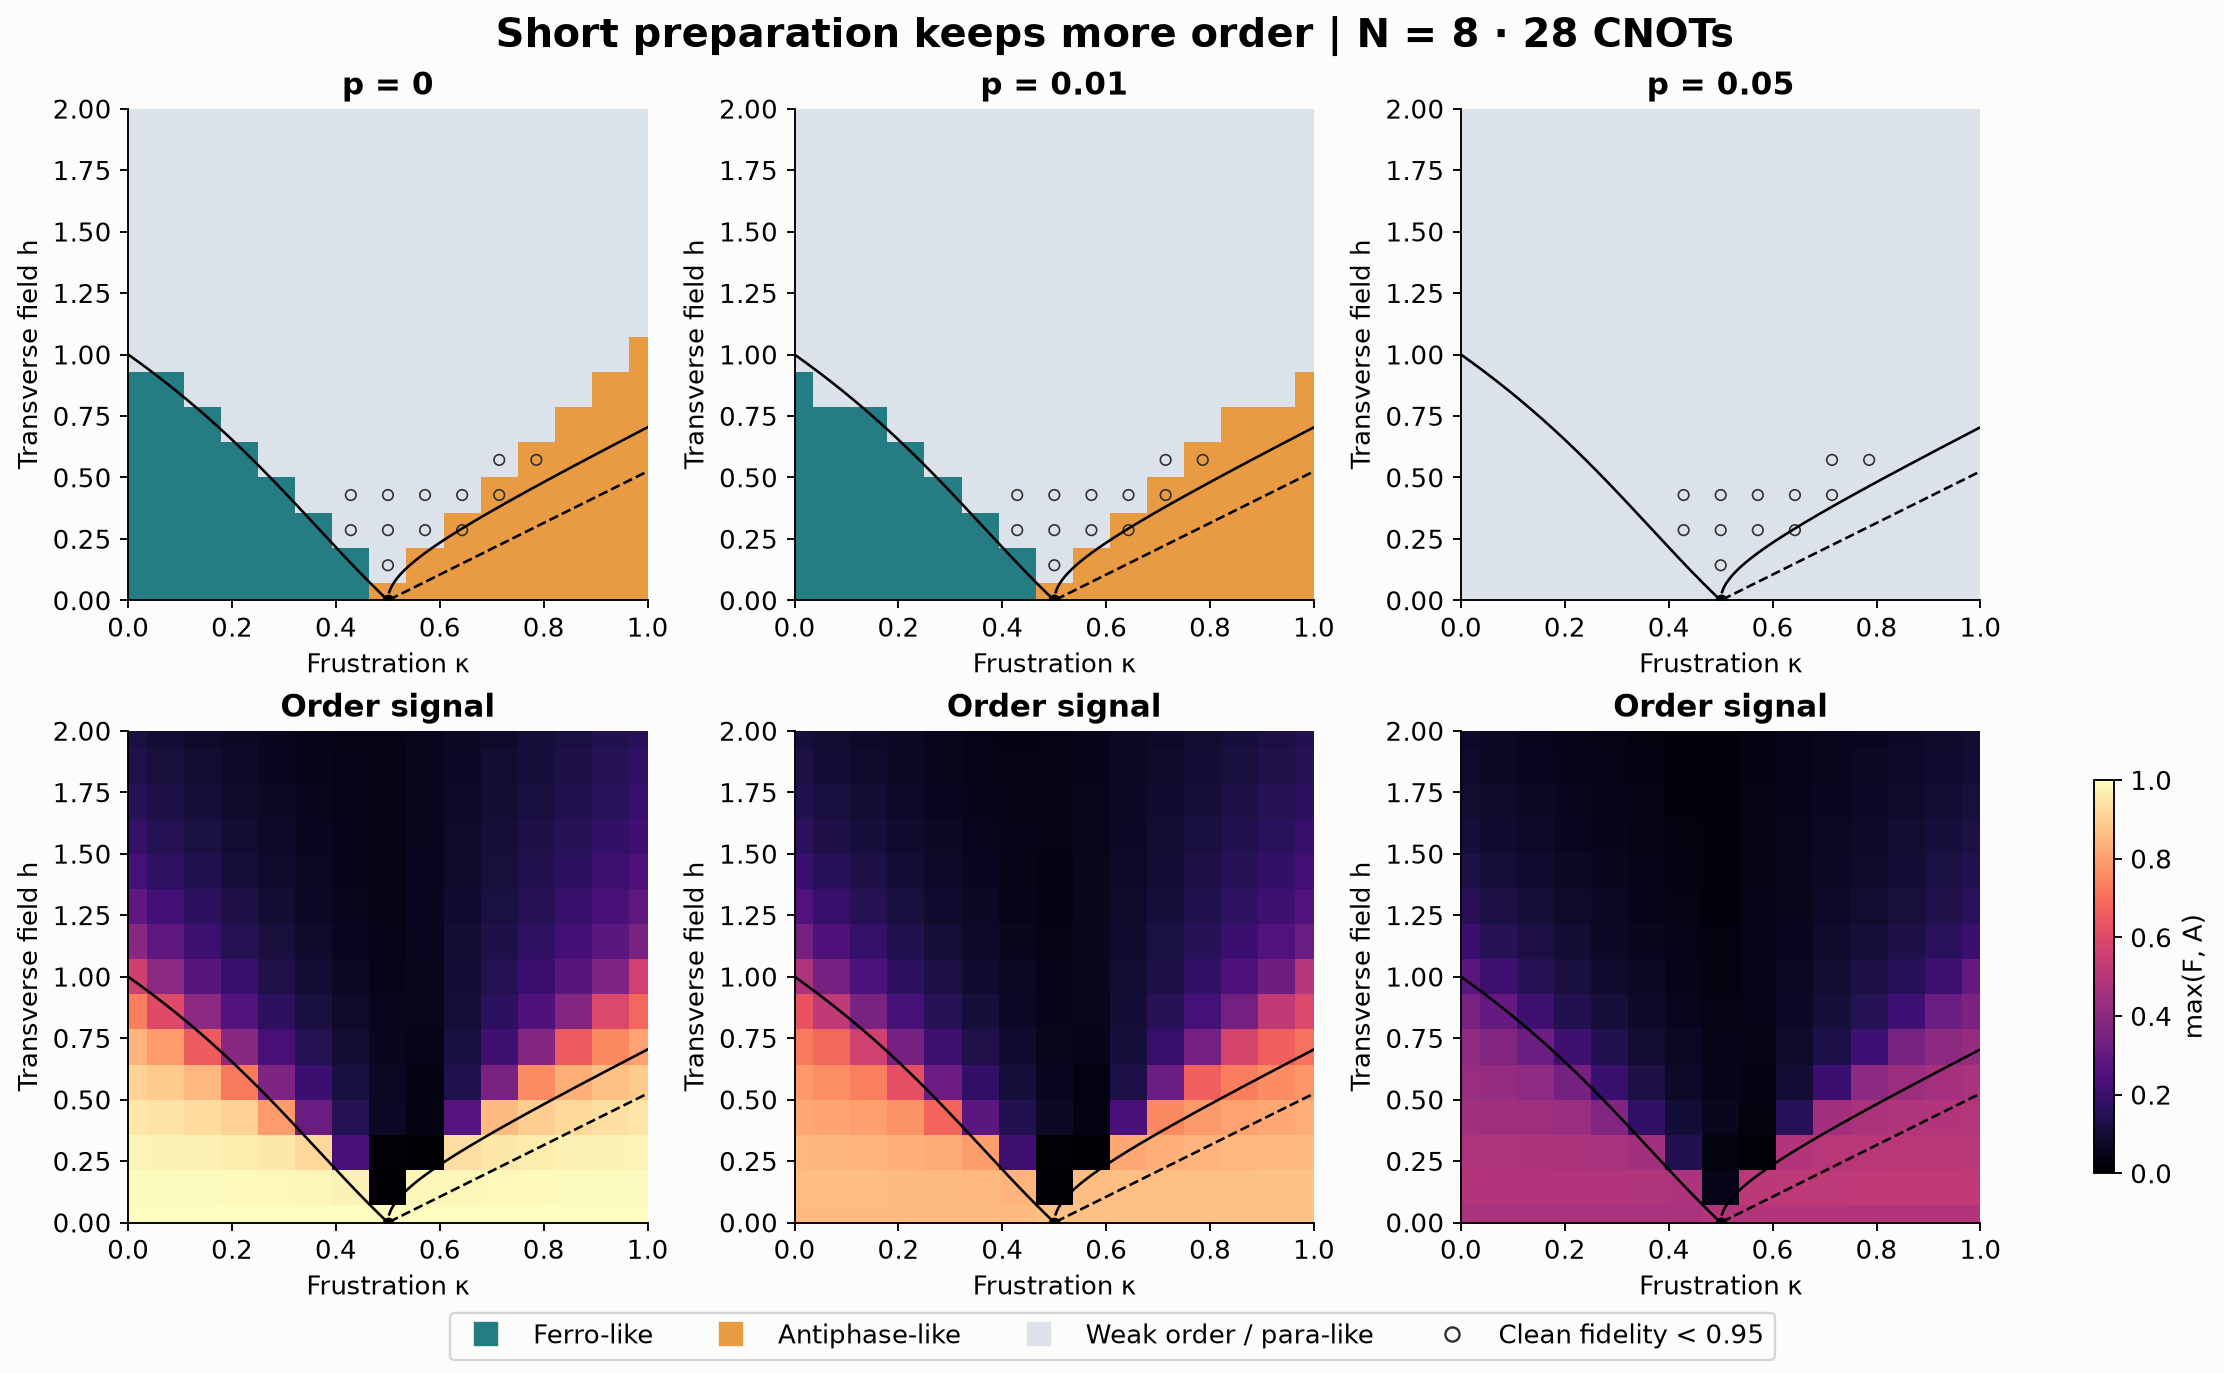

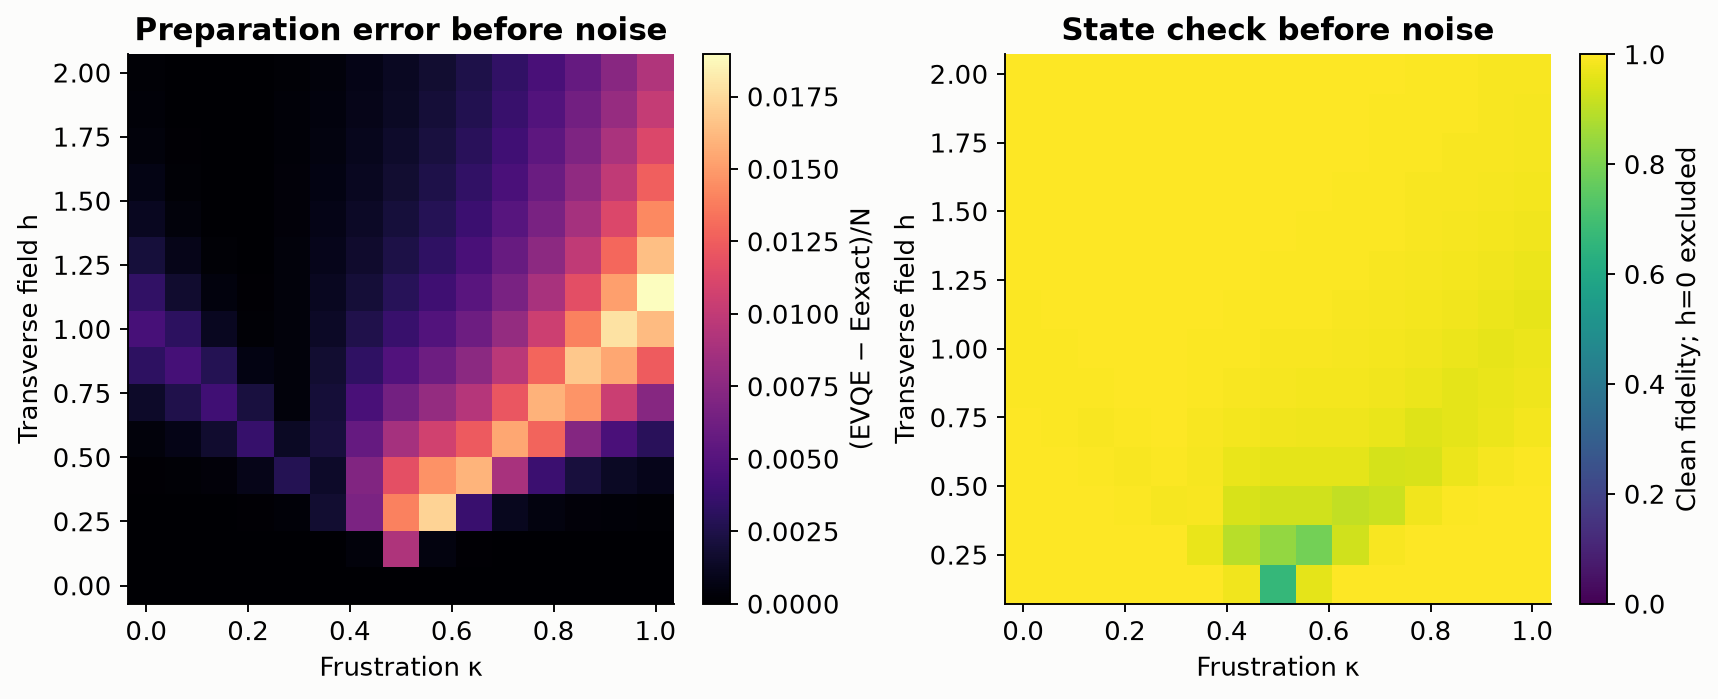

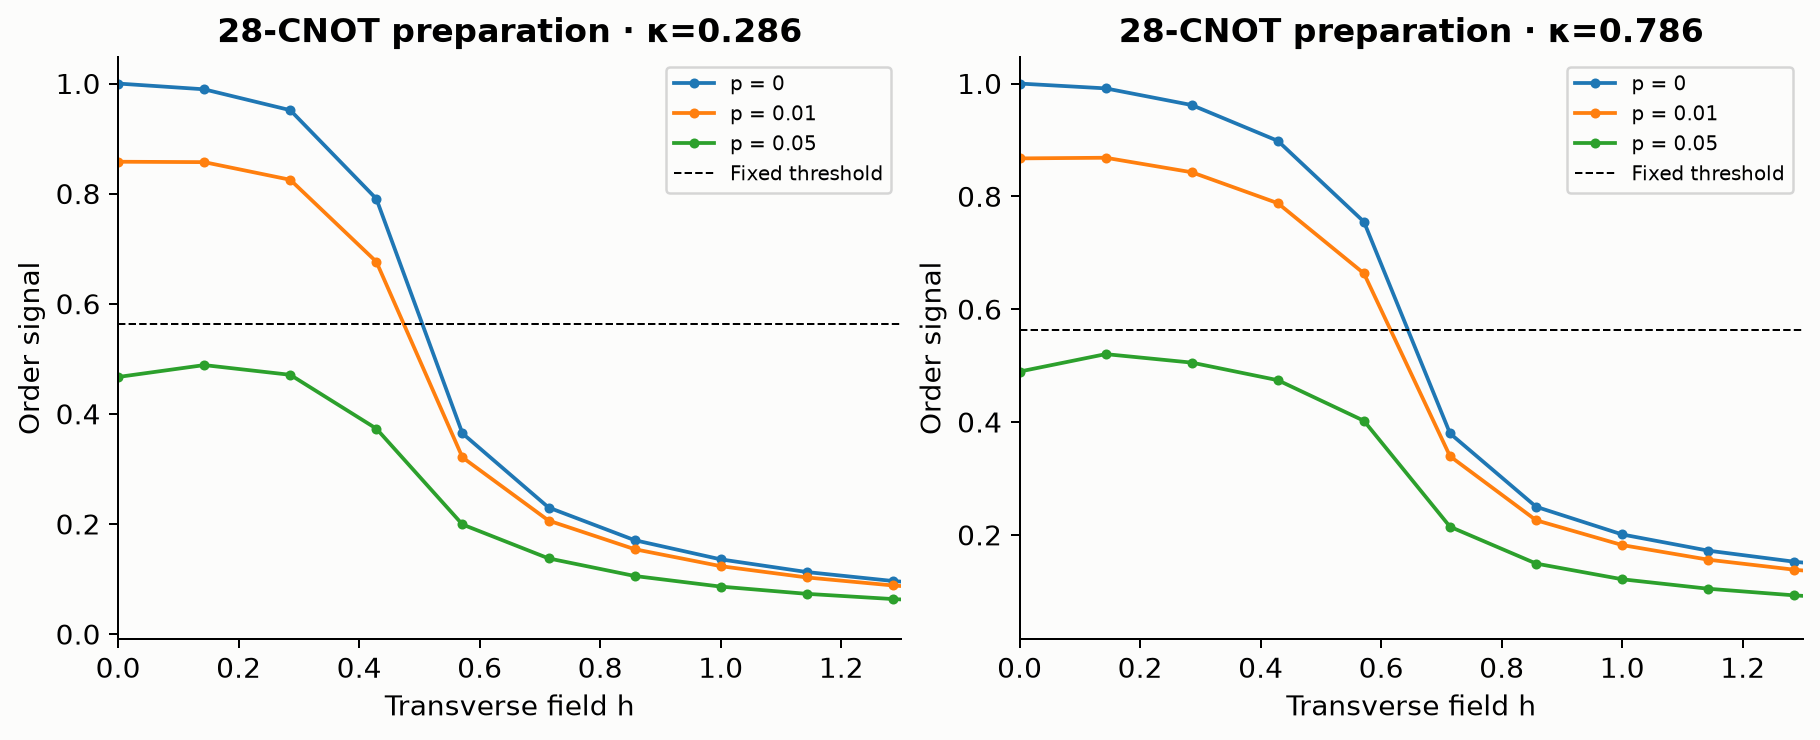

{
  "grid": [
    15,
    15
  ],
  "cnot_count": 28,
  "threshold": 0.5628839496768857,
  "clean_label_agreement_with_exact": 0.9822222222222222,
  "clean_reference_agreement_outside_floating": 0.9523809523809523,
  "mean_clean_energy_error_per_site": 0.00400684496273185,
  "max_clean_energy_error_per_site": 0.018955375668496588,
  "mean_clean_fidelity_h_positive": 0.9851863083829894,
  "min_clean_fidelity_h_positive": 0.6645885120493142,
  "optimizer_success_count": 196,
  "max_trace_error": 2.220446049250313e-15,
  "high_energy_error_count": 102,
  "low_clean_fidelity_positive_field_count": 12,
  "noise": [
    {
      "p": 0.0,
      "counts": [
        34,
        36,
        155
      ],
      "clean_VQE_label_agreement": 1.0,
      "exact_clean_label_agreement": 0.9822222222222222,
      "ferro_recall": 1.0,
      "anti_recall": 1.0,
      "mean_fidelity_h_positive": 0.9851863083829894,
      "mean_purity": 1.0
    },
    {
      "p": 0.01,
      "counts": [
        33,
        

In [6]:
vsummary=json.loads((ROOT/'data/variational_summary.json').read_text())
display(Image(filename=str(ROOT/'figures/variational_triptych.png')))
display(Image(filename=str(ROOT/'figures/variational_quality.png')))
display(Image(filename=str(ROOT/'figures/variational_boundaries.png')))
print(json.dumps(vsummary,indent=2))


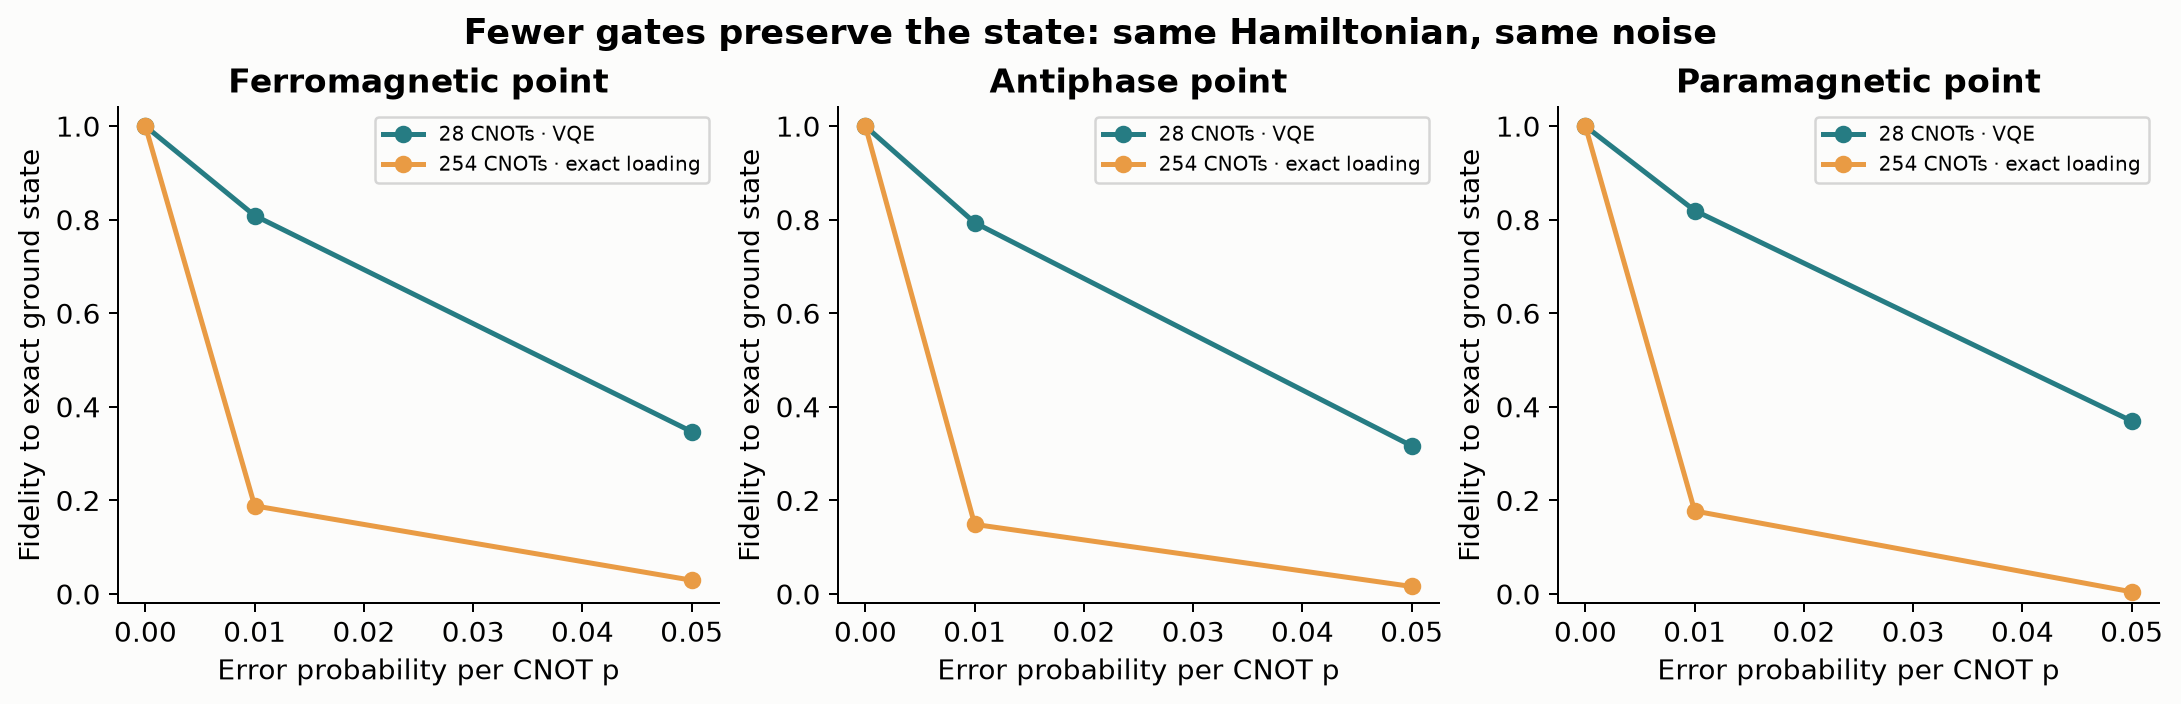

Shots per batch: 1024
Number of batches: 2000
ferromagnetic shallow correct fraction: 1.0
ferromagnetic exact_loader correct fraction: 0.0
antiphase shallow correct fraction: 1.0
antiphase exact_loader correct fraction: 0.0
paramagnetic shallow correct fraction: 1.0
paramagnetic exact_loader correct fraction: 1.0


In [7]:
display(Image(filename=str(ROOT/'figures/circuit_comparison.png')))
shot_check=json.loads((ROOT/'data/finite_shots.json').read_text())
print('Shots per batch:',shot_check['shots_per_repetition'])
print('Number of batches:',shot_check['repetitions'])
for row in shot_check['rows']:
    if row['p']==.01:
        print(row['phase'],row['preparation'],'correct fraction:',row['correct_label_fraction'])


## 5. Mitigation test

We also simulate 2p. Linear zero-noise extrapolation uses Cest(0)=2C(p)−C(2p). It removes the first-order term when a smooth low-noise expansion is useful. It can retain a large bias when many gates accumulate error.

This test changes the numerical channel strength. It is not a hardware folding experiment. For independent estimates with the same variance, the coefficients 2 and −1 multiply variance by five. Saved maps use exact expectations and have no shot variance.


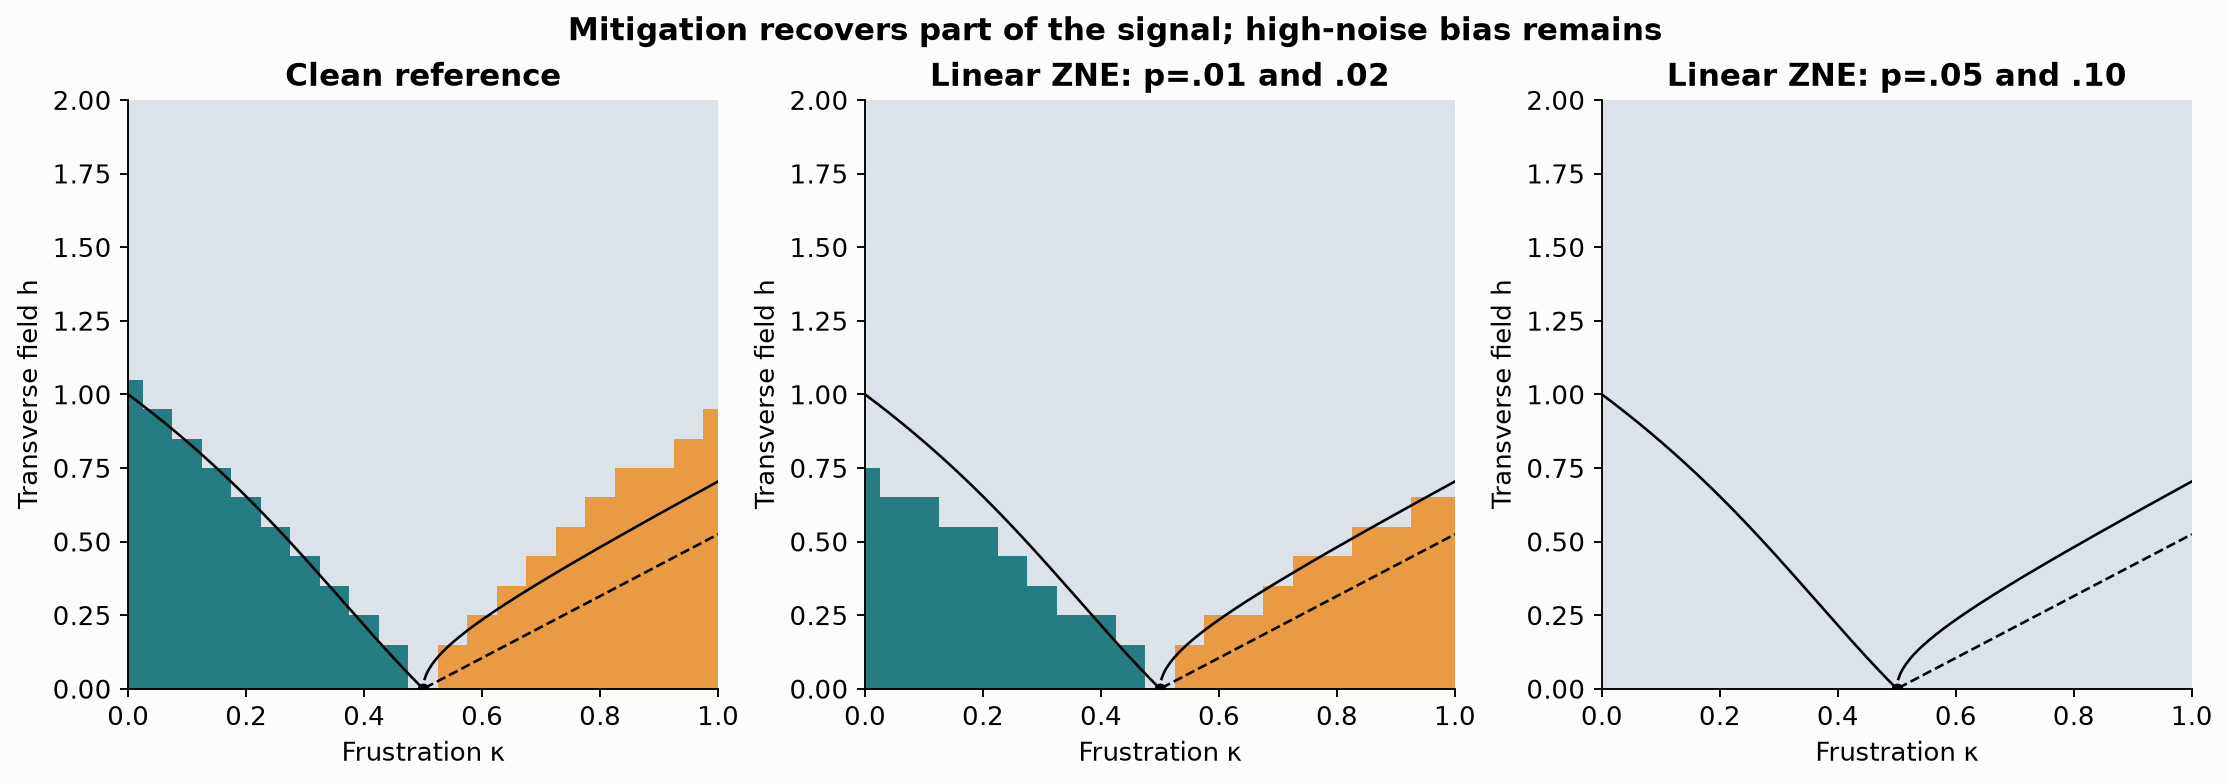

p: 0.01 correlation MAE: 0.14234134290261435 ZNE MAE: 0.09322576978536899
p: 0.05 correlation MAE: 0.24313332044920044 ZNE MAE: 0.21504048686631386


In [8]:
display(Image(filename=str(ROOT/'figures/mitigation.png')))
for row in summary['noise']:
    print('p:',row['p'],'correlation MAE:',row['correlation_MAE'],
          'ZNE MAE:',row['zne_correlation_MAE'])


## 6. Readout control and physical meaning

Direct Z measurement obtains every ZZ correlation without a CNOT. Thus this readout has no gate noise under the task model.

For a separate circuit test, a routed parity measurement over distance d uses 3(d−1)+1 CNOTs. Its exact signal is C(d)(1−4p/3)^(2d−1). The adjoint propagation and PennyLane checks agree. Analytic inversion recovers the mean only under the exact known model. It increases variance.

This optional test shows why a phase-robustness claim must specify the circuit. It is not used in the main preparation-noise maps.


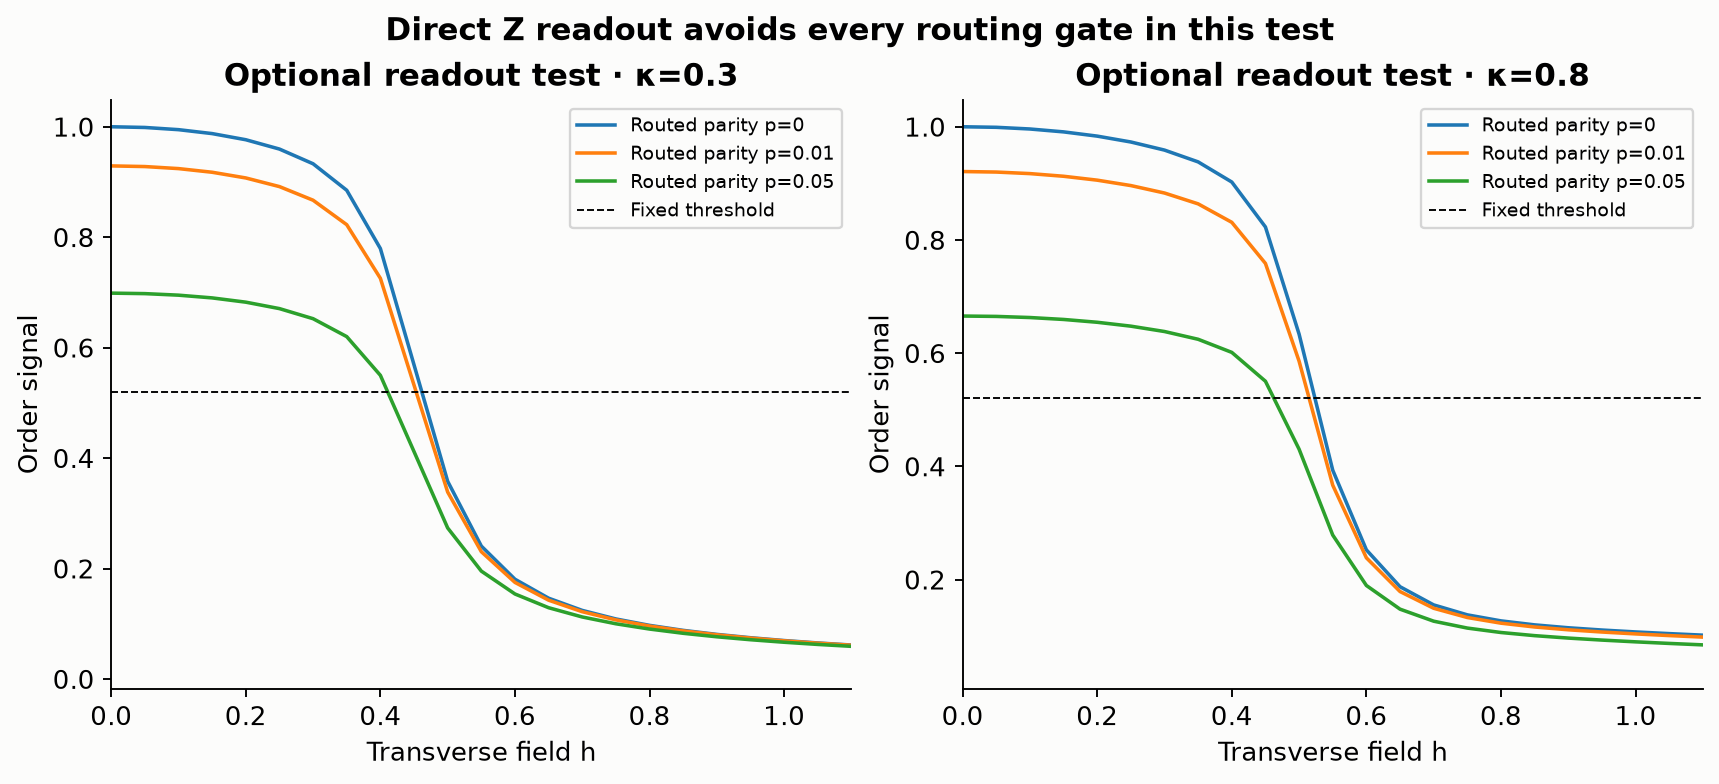

In [9]:
display(Image(filename=str(ROOT/'figures/readout_control.png')))

## 7. Limits and sources

N≤16 cannot settle the thermodynamic floating phase. Intermediate wavevectors can also occur in a gapped modulated paramagnet. The preparation circuit is an expensive exact-loading baseline. Its noise sensitivity does not establish an unavoidable limit for short VQE circuits. The main classifier is deliberately fixed before noise is applied.

Sources: [challenge](https://github.com/benmcdonough20/QSITE-2026-QuantumCoalition), [PennyLane ANNNI](https://pennylane.ai/demos/tutorial_annni), [noise convention](https://pennylane.ai/challenges/heisenberg_model), [Cea et al.](https://arxiv.org/abs/2402.11022), [Möttönen](https://docs.pennylane.ai/en/stable/code/api/pennylane.MottonenStatePreparation.html), [zero-noise extrapolation](https://arxiv.org/abs/1612.02058).


## 8. Full source

The following cells display the exact implementation used for the data and figures.

In [10]:
display(Code(filename=str(ROOT/'phaseguard.py'), language='python'))

"""PhaseGuard: finite ANNNI ground states and gate-noisy correlation readout.

All noise maps use ideal state injection. The circuit is a destructive parity
readout on a ring. This is not a noisy ground-state preparation algorithm.
"""
from __future__ import annotations

import argparse
import json
import time
from pathlib import Path

import numpy as np
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

ROOT = Path(__file__).resolve().parent
SEED = 20260925


class ANNNI:
    def __init__(self, n):
        if n % 4:
            raise ValueError("Use N divisible by four to fit the period-four state.")
        self.n = n
        self.ids = np.arange(2**n, dtype=np.int64)
        self.z = 1.0 - 2.0 * ((self.ids[:, None] >> np.arange(n-1, -1, -1)) & 1)
        self.nn = -(self.z * np.roll(self.z, -1, axis=1)).sum(axis=1)
        self.nnn = (self.z * np.roll(self.z, -2, axis=1)).sum(axis=1)
        rows = np.repeat(self.ids, n)
        cols = (self.ids[:, None] ^ (1 << np.arange(n))).ravel()
        self.flip = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(2**n, 2**n))
        # Exact even global-spin-flip sector. At low h the even/odd splitting
        # falls below machine precision; a full-space solver can mix them and
        # create false fidelity spikes even while its residual is small.
        half = 2**(n-1)
        reps = np.arange(half)
        flipped = reps[:,None] ^ (1 << np.arange(n))
        even_cols = np.minimum(flipped, 2**n-1-flipped).ravel()
        self.even_flip = csr_matrix((np.ones(half*n),(np.repeat(reps,n),even_cols)),shape=(half,half))
        self.corr_diag = np.array([(self.z * np.roll(self.z, -d, axis=1)).mean(axis=1)
                                   for d in range(n)])

    def hamiltonian(self, kappa, h):
        return diags(self.nn + kappa*self.nnn, format="csr") - h*self.flip

    def ground(self, kappa, h, initial=None):
        diag = self.nn + kappa*self.nnn
        if h == 0:
            support = np.isclose(diag, diag.min(), atol=1e-12)
            state = support.astype(float) / np.sqrt(support.sum())
            return float(diag.min()), state, 0.0
        half = len(diag)//2
        ham = diags(diag[:half],format="csr") - h*self.even_flip
        if initial is None:
            initial = np.ones(half) / np.sqrt(half)
        else:
            initial = (initial[:half]+initial[half:][::-1])/np.sqrt(2)
            initial /= np.linalg.norm(initial)
        # For h>0, Perron-Frobenius fixes the ground state in the even sector.
        vals, states = eigsh(ham, k=1, which="SA", v0=initial, tol=1e-11, maxiter=5000)
        sector_state = states[:,0]
        state = np.concatenate([sector_state,sector_state[::-1]])/np.sqrt(2)
        if state.sum() < 0:
            state = -state
        residual = float(np.linalg.norm(self.hamiltonian(kappa,h) @ state - vals[0]*state))
        return float(vals[0]), state, residual

    def observables(self, state):
        prob = np.abs(state)**2
        corr = self.corr_diag @ prob
        mx = float(state @ (self.flip @ state) / self.n)
        return corr, mx


def reference(k):
    k = np.asarray(k, float)
    ising = np.full_like(k, np.nan)
    mask = k < .5
    # Algebraically rationalized expression: exact limit h_I(0)=1.
    ising[mask] = 2*(1-2*k[mask]) / (1+np.sqrt((1-3*k[mask]+4*k[mask]**2)/(1-k[mask])))
    lower = np.where(k > .5, 1.05*(k-.5), np.nan)
    upper = np.where(k > .5, 1.05*np.sqrt(np.maximum(0, (k-.5)*(k-.1))), np.nan)
    return ising, lower, upper


def readout_gates(n, i, j):
    """Route i along the shortest ring path, then read ZZ as Z on j."""
    clockwise = (j-i) % n
    step = 1 if clockwise <= n/2 else -1
    distance = min(clockwise, n-clockwise)
    if distance == 0:
        return []
    route = [(i+step*s) % n for s in range(distance+1)]
    gates = []
    for a, b in zip(route[:-2], route[1:-1]):
        gates.extend([(a,b), (b,a), (a,b)])
    gates.append((route[-2], j))
    re

In [11]:
display(Code(filename=str(ROOT/'noisy_preparation.py'), language='python'))

"""Exact density-matrix simulation of PennyLane's compiled Möttönen circuits.

The same qml operation list is used by the reference default.mixed simulator.
The specialized implementation is real valued; this ground-state problem has
real nonnegative amplitudes. It rejects nonzero complex rotations.
"""
from __future__ import annotations
import argparse
import json
import time
import numpy as np
import pennylane as qml
from phaseguard import ANNNI, ROOT, SEED, order, classify


class RealDensity:
    def __init__(self,n):
        self.n=n
        self.dim=2**n
        ids=np.arange(self.dim)
        self.flip={t: ids ^ (1<<(n-1-t)) for t in range(n)}
        self.zero={t: ids[((ids>>(n-1-t))&1)==0] for t in range(n)}
        self.same={t: (((ids[:,None]^ids[None,:])>>(n-1-t))&1)==0 for t in range(n)}
        self.perm={(c,t):ids ^ (((ids>>(n-1-c))&1) << (n-1-t))
                   for c in range(n) for t in range(n) if c!=t}

    def run(self,gates,p):
        rho=np.zeros((self.dim,self.dim))
        rho[0,0]=1
        for gate in gates:
            if gate.name == "RY":
                angle=float(gate.data[0]); wire=int(gate.wires[0])
                c,s=np.cos(angle/2),np.sin(angle/2)
                a=self.zero[wire]; b=self.flip[wire][a]
                ra,rb=rho[a,:].copy(),rho[b,:].copy()
                rho[a,:]=c*ra-s*rb; rho[b,:]=s*ra+c*rb
                ra,rb=rho[:,a].copy(),rho[:,b].copy()
                rho[:,a]=c*ra-s*rb; rho[:,b]=s*ra+c*rb
            elif gate.name == "CNOT":
                c,t=map(int,gate.wires); perm=self.perm[c,t]
                rho=rho[np.ix_(perm,perm)]
                if p:
                    flipped=rho[np.ix_(self.flip[t],self.flip[t])]
                    same=self.same[t]
                    # Blocks diagonal in target Z mix with their flipped block.
                    # Off-diagonal target blocks shrink by 1-4p/3.
                    rho=np.where(same,(1-2*p/3)*rho+(2*p/3)*flipped,(1-4*p/3)*rho)
            elif gate.name == "GlobalPhase":
                pass
            elif gate.name == "RZ" and abs(float(gate.data[0]))<1e-12:
                pass
            else:
                raise ValueError(f"Unsupported gate: {gate}")
        return rho


def compile_state(state,n):
    # For h>0 the stoquastic ground state is positive. Remove tiny eigensolver
    # roundoff in tails only; the norm of this change is checked and recorded.
    if np.min(state)<-1e-9:
        raise ValueError("Ground state is not nonnegative.")
    positive=np.maximum(state,0)
    positive/=np.linalg.norm(positive)
    error=float(np.linalg.norm(positive-state))
    assert error<1e-8
    return qml.MottonenStatePreparation(positive,wires=range(n)).decomposition(),positive,error


def validate():
    records=[]
    for n in [4,8]:
        model=ANNNI(n); engine=RealDensity(n)
        for k,h in [(.15,.25),(.85,.2),(.2,1.5)]:
            _,state,_=model.ground(k,h)
            gates,state,error=compile_state(state,n)
            for p in [0,.01,.05]:
                rho=engine.run(gates,p)
                @qml.qnode(qml.device("default.mixed",wires=n))
                def reference():
                    for gate in gates:
                        qml.apply(gate)
                        if gate.name=="CNOT":
                            qml.DepolarizingChannel(p,wires=gate.wires[1])
                    return qml.density_matrix(wires=range(n))
                ref=np.asarray(reference())
                err=float(np.max(abs(rho-ref)))
                trace=abs(float(np.trace(rho))-1)
                minimum=float(np.linalg.eigvalsh(rho).min())
                assert err<1e-9 and trace<1e-10 and minimum>-1e-10
                if p==0: assert abs(float(state@rho@state)-1)<1e-10
                records.append(dict(n=n,kappa=k,h=h,p=p,matrix_max_error=err,
                                    trace_error=trace,minimum_eigenvalue=minimum))
                print(records[-1],flush=True)
    (ROOT/"data/density_val

In [12]:
display(Code(filename=str(ROOT/'analyze.py'), language='python'))

"""Build every figure and numeric summary from the saved experiment data."""
import csv
import json
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from phaseguard import ROOT,ANNNI,reference,attenuation,order,classify,crossing

plt.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
                     "axes.spines.right":False,"figure.facecolor":"#fcfcfb","axes.facecolor":"#fcfcfb",
                     "savefig.facecolor":"#fcfcfb","axes.titleweight":"bold"})
COLORS=["#267c83","#e99b44","#dce2e9"]
CMAP=ListedColormap(COLORS)
FIG=ROOT/"figures"; FIG.mkdir(exist_ok=True)


def threshold(n):
    m=ANNNI(n); _,s,_=m.ground(0,1)
    return float(order(m.observables(s)[0])[0])


def overlay(ax):
    k=np.linspace(0,1,401); a,b,c=reference(k)
    ax.plot(k,a,"k-",lw=1.1)
    ax.plot(k,c,"k-",lw=1.1)
    ax.plot(k,b,"k--",lw=1.1)
    ax.plot(.5,0,"ko",ms=4)
    ax.set(xlim=(0,1),ylim=(0,2),xlabel="Frustration κ",ylabel="Transverse field h")


def map_plot(ax,grid,values,title,categorical=True):
    if categorical:
        im=ax.pcolormesh(grid["kappa"],grid["h"],values,cmap=CMAP,vmin=-.5,vmax=2.5,shading="nearest")
    else:
        im=ax.pcolormesh(grid["kappa"],grid["h"],values,cmap="magma",vmin=0,vmax=1,shading="nearest")
    overlay(ax); ax.set_title(title)
    return im


def reference_labels(ks,hs):
    k,h=np.meshgrid(ks,hs); left,lower,upper=reference(ks)
    labels=np.full(k.shape,2)
    labels[(k<.5)&(h<left[None,:])]=0
    labels[(k>.5)&(h<upper[None,:])]=1
    mask=(k!=.5)&(h>0)&~((k>.5)&(h>=lower[None,:])&(h<=upper[None,:]))
    return labels,mask


def run():
    clean=np.load(ROOT/"data/grid_N12.npz")
    prep=np.load(ROOT/"data/preparation_grid_N8.npz")
    mit=np.load(ROOT/"data/mitigation_grid_N8.npz")
    t8,t12=threshold(8),threshold(12)
    c=prep["corr"]
    labels=np.array([classify(x,t8) for x in c])
    f,a,s=order(c)
    zne=np.array([2*c[1]-mit["corr"][1],2*c[2]-mit["corr"][2]])
    zlabels=np.array([classify(x,t8) for x in zne])
    ref,mask=reference_labels(prep["kappa"],prep["h"])
    counts=[{name:int(np.sum(l==i)) for i,name in enumerate(["ferro","anti","weak_order"])} for l in labels]
    summary={"N8_threshold":t8,"N12_threshold":t12,"N8_grid_shape":list(labels.shape[1:]),
             "N12_grid_shape":list(clean["energy"].shape),"preparation_CNOT_range":[int(prep["cnot_count"].min()),int(prep["cnot_count"].max())],
             "preparation_max_trace_error":float(abs(prep["trace"]-1).max()),
             "N12_max_residual":float(clean["residual"].max()),"phase_counts":counts,
             "reference_agreement_N8_clean_outside_floating_band":float(np.mean(labels[0][mask]==ref[mask])),
             "grid_spacing":{"N8_h":float(prep["h"][1]-prep["h"][0]),"N12_h":float(clean["h"][1]-clean["h"][0])},
             "noise":[],"threshold_sensitivity":[]}
    for ip,p in enumerate([.01,.05],1):
        record={"p":p,"label_agreement_with_clean":float(np.mean(labels[ip]==labels[0])),
                "ferro_recall":float(np.mean(labels[ip][labels[0]==0]==0)),
                "anti_recall":float(np.mean(labels[ip][labels[0]==1]==1)),
                "correlation_MAE":float(np.mean(abs(c[ip,...,1:]-c[0,...,1:]))),
                "zne_label_agreement_with_clean":float(np.mean(zlabels[ip-1]==labels[0])),
                "zne_recovered_ordered_labels":int(np.sum((zlabels[ip-1]==labels[0])&(labels[0]!=2))),
                "zne_false_positive_ordered_labels":int(np.sum((zlabels[ip-1]!=2)&(labels[0]==2))),
                "zne_correlation_MAE":float(np.mean(abs(zne[ip-1,...,1:]-c[0,...,1:]))),
                "mean_ground_state_fidelity":float(prep["fidelity"][ip].mean()),
                "mean_purity":float(prep["purity"][ip].mean())}
        summary["noise"].append(record)
    for t in [.25,.4,t8]:
        summary["thresh

In [13]:
display(Code(filename=str(ROOT/'analyze_variational.py'), language='python'))

"""Analyze the independent 15x15 short-circuit map after it is copied here."""
import json
import numpy as np
import matplotlib.pyplot as plt
from analyze import ROOT,FIG,COLORS,CMAP,map_plot,reference_labels,Line2D
from phaseguard import order,classify,crossing


def run():
    folder=ROOT/'variational_map'
    z=np.load(folder/'variational_grid_N8.npz')
    assert z['complete'].all() and z['corr'].shape==(3,15,15,8)
    t=float(z['threshold']);labels=np.array([classify(c,t) for c in z['corr']])
    exact=classify(z['exact_corr'],t)
    f,a,_=order(z['corr'])
    uncertain=z['fidelity'][0]<.95
    uncertain[0,:]=False  # h=0 needs a ground-space metric, not one state.
    uh,uk=np.where(uncertain)
    def mark_uncertain(ax):
        ax.scatter(z['kappa'][uk],z['h'][uh],s=20,facecolors='none',edgecolors='#303030',lw=.7)
    ref,mask=reference_labels(z['kappa'],z['h'])
    result=dict(grid=[15,15],cnot_count=28,threshold=t,
                clean_label_agreement_with_exact=float(np.mean(labels[0]==exact)),
                clean_reference_agreement_outside_floating=float(np.mean(labels[0][mask]==ref[mask])),
                mean_clean_energy_error_per_site=float(z['clean_energy_error_per_site'].mean()),
                max_clean_energy_error_per_site=float(z['clean_energy_error_per_site'].max()),
                mean_clean_fidelity_h_positive=float(z['fidelity'][0,1:].mean()),
                min_clean_fidelity_h_positive=float(z['fidelity'][0,1:].min()),
                optimizer_success_count=int(z['optimizer_success'].sum()),
                max_trace_error=float(abs(z['trace']-1).max()),
                high_energy_error_count=int(np.sum(z['clean_energy_error_per_site']>.0025)),
                low_clean_fidelity_positive_field_count=int(uncertain.sum()),
                noise=[],boundaries=[])
    for ip,p in enumerate(z['p']):
        result['noise'].append(dict(p=float(p),counts=np.bincount(labels[ip].ravel(),minlength=3).tolist(),
                                   clean_VQE_label_agreement=float(np.mean(labels[ip]==labels[0])),
                                   exact_clean_label_agreement=float(np.mean(labels[ip]==exact)),
                                   ferro_recall=float(np.mean(labels[ip][labels[0]==0]==0)),
                                   anti_recall=float(np.mean(labels[ip][labels[0]==1]==1)),
                                   mean_fidelity_h_positive=float(z['fidelity'][ip,1:].mean()),
                                   mean_purity=float(z['purity'][ip].mean())))
    for target in [0,.3,.6,.8,1.]:
        j=int(np.argmin(abs(z['kappa']-target)));k=float(z['kappa'][j])
        for ip,p in enumerate(z['p']):
            val=f[ip,:,j] if k<.5 else a[ip,:,j]
            value=crossing(z['h'],val,t)
            bracket=None if value is None else min(int(np.searchsorted(z['h'],value)),len(z['h'])-1)
            flag=None if bracket is None else bool(uncertain[max(0,bracket-1):bracket+1,j].any())
            result['boundaries'].append(dict(kappa=k,p=float(p),h=value,uncertain_preparation_in_bracket=flag))
    (ROOT/'data/variational_summary.json').write_text(json.dumps(result,indent=2))
    legend=[Line2D([0],[0],marker='s',linestyle='',color=col,markersize=9,label=name)
            for col,name in zip(COLORS,['Ferro-like','Antiphase-like','Weak order / para-like'])]
    legend.append(Line2D([0],[0],marker='o',linestyle='',color='#303030',markerfacecolor='none',
                         markersize=6,label='Clean fidelity < 0.95'))
    fig,axs=plt.subplots(2,3,figsize=(13,8),layout='constrained')
    for ip,p in enumerate(z['p']):
        map_plot(axs[0,ip],z,labels[ip],f'p = {p:g}')
        mark_uncertain(axs[0,ip])
        im=map_plot(axs[1,ip],z,np.maximum(f[ip],a[ip]),'Order signal',False)
    fig.colorbar(im,ax=axs[1,:],label='max(F, A)',shrink=.8)
    fig.legend(handles=legend,loc='outside lower center',ncols=4)
    fig.suptitle('Short preparation keeps more order | N = 8 · 28 CNOTs',fontsize=17,fontweight='

In [14]:
display(Code(filename=str(ROOT/'finite_shots.py'), language='python'))

"""Finite-shot stress test at three saved control points.

Each repetition samples the full Z bitstring distribution. All pair estimates
therefore have the covariance of a shared measurement batch.
"""
import json
import numpy as np
import pennylane as qml
from phaseguard import ROOT, ANNNI, order
from noisy_preparation import RealDensity,compile_state


def run(shots=1024,repeats=2000):
    rng=np.random.default_rng(20260925)
    model=ANNNI(8);engine=RealDensity(8)
    f_values,a_values,_=order(model.corr_diag.T)
    threshold=.5628839496768858
    rows=[]
    controls=json.loads((ROOT/'variational_control/symmetry_results.json').read_text())['records']
    for record in controls:
        _,state,_=model.ground(record['kappa'],record['h'])
        full,_,_=compile_state(state,8)
        with qml.tape.QuantumTape() as tape:
            for layer in np.array(record['parameters']).reshape(4,8):
                for q,theta in enumerate(layer):qml.RY(theta,wires=q)
                for q in range(7):qml.CNOT(wires=[q,q+1])
        for kind,gates in [('shallow',tape.operations),('exact_loader',full)]:
            for p in [0,.01,.05]:
                rho=engine.run(gates,p)
                prob=np.maximum(0,np.diag(rho));prob/=prob.sum()
                counts=rng.multinomial(shots,prob,size=repeats)
                ff=counts@f_values/shots;aa=counts@a_values/shots
                label=np.full(repeats,2);label[(ff>=aa)&(ff>=threshold)]=0
                label[(aa>ff)&(aa>=threshold)]=1
                target={'ferromagnetic':0,'antiphase':1,'paramagnetic':2}[record['phase_point']]
                rows.append(dict(phase=record['phase_point'],preparation=kind,p=p,
                                 correct_label_fraction=float(np.mean(label==target)),
                                 ferro_interval_95=np.quantile(ff,[.025,.975]).tolist(),
                                 anti_interval_95=np.quantile(aa,[.025,.975]).tolist(),
                                 ferro_exact=float(prob@f_values),anti_exact=float(prob@a_values)))
    result=dict(seed=20260925,shots_per_repetition=shots,repetitions=repeats,
                interpretation='Empirical 2.5 and 97.5 percentiles of repeated samples; ideal direct Z measurement.',rows=rows)
    (ROOT/'data/finite_shots.json').write_text(json.dumps(result,indent=2))
    for row in rows: print(row['phase'],row['preparation'],row['p'],row['correct_label_fraction'])


if __name__=='__main__':run()

In [15]:
display(Code(filename=str(ROOT/'variational_control/run_control.py'), language='python'))

"""Shallow PennyLane variational preparation for three ANNNI control points.

This uses 4 layers of 8 RY rotations and 7 nearest-neighbor CNOT gates.
Clean parameters are optimized once, then held fixed for all noise values.
No reference phase curves or labels enter the objective.
"""
from __future__ import annotations

import argparse
import json
import platform
import sys
import time
from pathlib import Path

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from scipy.optimize import minimize

HERE = Path(__file__).resolve().parent
sys.path.insert(0, str(HERE.parent))
from phaseguard import ANNNI, order, structure

N = 8
LAYERS = 4
SEED = 250925


def ansatz(params, p=0.0, noisy=False):
    params = params.reshape(LAYERS,N)
    for row in params:
        for q in range(N):
            qml.RY(row[q],wires=q)
        for q in range(N-1):
            qml.CNOT(wires=[q,q+1])
            if noisy:
                qml.DepolarizingChannel(p,wires=q+1)


def seed_parameters(name):
    x = np.zeros((LAYERS,N))
    if name == 'ferromagnetic':
        x[-1,0] = np.pi/2
    elif name == 'paramagnetic':
        x[-1,:] = np.pi/2
    else:
        # A product antiphase in the final output. The inverse of a chain
        # CNOT layer gives the required input bits for that last layer.
        bits = np.array([0,0,1,1,0,0,1,1])
        before = bits ^ np.r_[0,bits[:-1]]
        x[-1,:] = np.pi*before
    return x.ravel()


def run(symmetry_weight=0.0, output='results.json', iterations=400):
    t0 = time.monotonic()
    rng = np.random.default_rng(SEED)
    model = ANNNI(N)
    records = []
    pure_dev = qml.device('lightning.qubit',wires=N)

    @qml.qnode(qml.device('default.qubit',wires=N))
    def pure_state(params):
        ansatz(params)
        return qml.state()

    for name,k,h in [('ferromagnetic',.1,.2),('antiphase',.9,.1),('paramagnetic',.2,1.8)]:
        exact_energy, exact_state, residual = model.ground(k,h)
        hamiltonian = sum([-qml.Z(q)@qml.Z((q+1)%N)
                           +k*qml.Z(q)@qml.Z((q+2)%N)-h*qml.X(q)
                           for q in range(N)])
        parity = qml.prod(*(qml.X(q) for q in range(N)))
        objective_hamiltonian = hamiltonian + symmetry_weight*(qml.Identity(0)-parity)

        @qml.qnode(pure_dev,interface='autograd',diff_method='adjoint')
        def energy(params):
            ansatz(params)
            return qml.expval(objective_hamiltonian)

        gradient = qml.grad(energy)

        def objective(x):
            x = pnp.array(x,requires_grad=True)
            return float(energy(x)), np.asarray(gradient(x),dtype=float)

        physical_seed = seed_parameters(name)
        starts = [physical_seed,
                  physical_seed+rng.normal(0,.15,LAYERS*N),
                  physical_seed+rng.normal(0,.4,LAYERS*N),
                  rng.uniform(-np.pi,np.pi,LAYERS*N),
                  rng.normal(0,.5,LAYERS*N),
                  np.full(LAYERS*N,np.pi/4)]
        if name == 'antiphase' and symmetry_weight > 0:
            symmetric_anti = np.zeros((LAYERS,N))
            symmetric_anti[-2,1] = -np.pi/2
            symmetric_anti[-1,0] = np.pi/2
            symmetric_anti[-1,[2,4,6]] = np.pi
            starts[0] = symmetric_anti.ravel()
        trials = []
        best = None
        for trial, x0 in enumerate(starts):
            fit = minimize(objective,x0,jac=True,method='L-BFGS-B',
                           options={'maxiter':iterations,'ftol':1e-13,'gtol':1e-7,'maxls':30})
            candidate = dict(trial=trial,objective=float(fit.fun),
                             iterations=int(fit.nit),evaluations=int(fit.nfev),
                             success=bool(fit.success),message=str(fit.message))
            trials.append(candidate)
            if best is None or fit.fun < best.fun:
                best = fit
            print(name,candidate,'elapsed',round(time.monotonic()-t0,1),flush=True)

        params = np.asarray(best.x)
        state

In [16]:
display(Code(filename=str(ROOT/'variational_map/run_map.py'), language='python'))

"""Bounded 15x15 shallow VQE map with explicit target-CNOT noise.

Optimize the clean energy plus a known global-spin-flip symmetry penalty.
Freeze those parameters for p=0, 0.01, 0.05. Compare every point with ED.
"""
from __future__ import annotations
import json
import sys
import time
from pathlib import Path

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from scipy.optimize import minimize

HERE=Path(__file__).resolve().parent
BASE=HERE.parent
sys.path.insert(0,str(BASE))
from phaseguard import ANNNI, classify
from noisy_preparation import RealDensity

N=8
LAYERS=4
POINTS=15
SEED=719834
THRESHOLD=.5628839496768857
SYMMETRY_WEIGHT=.5
MAXITER=200
RESCUE_ERROR_PER_SITE=.0025


def ansatz(x):
    for row in x.reshape(LAYERS,N):
        for q in range(N):
            qml.RY(row[q],wires=q)
        for q in range(N-1):
            qml.CNOT(wires=[q,q+1])


def main():
    t0=time.monotonic()
    rng=np.random.default_rng(SEED)
    model=ANNNI(N)
    engine=RealDensity(N)
    ks=np.linspace(0,1,POINTS)
    hs=np.linspace(0,2,POINTS)
    ps=np.array([0,.01,.05])
    shape=(POINTS,POINTS)
    complete=np.zeros(shape,bool)
    energy=np.full((3,)+shape,np.nan)
    corr=np.full((3,)+shape+(N,),np.nan)
    fidelity=np.full((3,)+shape,np.nan)
    ground_space_fidelity=np.full_like(fidelity,np.nan)
    purity=np.full_like(fidelity,np.nan)
    trace=np.full_like(fidelity,np.nan)
    exact_energy=np.full(shape,np.nan)
    exact_corr=np.full(shape+(N,),np.nan)
    parameters=np.full(shape+(LAYERS*N,),np.nan)
    objective_value=np.full(shape,np.nan)
    parity_value=np.full(shape,np.nan)
    error_per_site=np.full(shape,np.nan)
    optimizer_success=np.zeros(shape,bool)
    iteration_count=np.zeros(shape,int)
    evaluation_count=np.zeros(shape,int)
    trial_count=np.zeros(shape,int)
    residual=np.full(shape,np.nan)
    trials=[]

    control=json.loads((BASE/'variational_control/symmetry_results.json').read_text())
    fixed_seeds=[np.array(r['parameters']) for r in control['records']]
    exact_ferro=np.zeros((LAYERS,N));exact_ferro[-1,0]=np.pi/2
    exact_anti=np.zeros((LAYERS,N));exact_anti[-2,1]=-np.pi/2
    exact_anti[-1,0]=np.pi/2;exact_anti[-1,[2,4,6]]=np.pi
    exact_para=np.zeros((LAYERS,N));exact_para[-1,:]=np.pi/2
    fixed_seeds += [exact_ferro.ravel(),exact_anti.ravel(),exact_para.ravel()]
    parity=qml.prod(*(qml.X(q) for q in range(N)))
    dev=qml.device('lightning.qubit',wires=N)

    @qml.qnode(qml.device('default.qubit',wires=N))
    def state_circuit(x):
        ansatz(x)
        return qml.state()

    def save(final=False):
        name='variational_grid_N8.npz' if final else 'variational_partial.npz'
        np.savez_compressed(HERE/name,kappa=ks,h=hs,p=ps,corr=corr,
                            energy=energy,fidelity=fidelity,
                            ground_space_fidelity=ground_space_fidelity,
                            purity=purity,trace=trace,exact_energy=exact_energy,
                            exact_corr=exact_corr,parameters=parameters,
                            objective_value=objective_value,global_x_parity=parity_value,
                            clean_energy_error_per_site=error_per_site,
                            optimizer_success=optimizer_success,
                            iteration_count=iteration_count,evaluation_count=evaluation_count,
                            trial_count=trial_count,ed_residual=residual,complete=complete,
                            cnot_count=np.full(shape,28),threshold=THRESHOLD)
        meta=dict(seed=SEED,n=N,layers=LAYERS,points=POINTS,noise_values=ps.tolist(),
                  cnot_count=28,rotation_count=32,max_iterations_per_trial=MAXITER,
                  max_rescue_trials=2,rescue_energy_error_per_site=RESCUE_ERROR_PER_SITE,
                  symmetry_penalty_weight=SYMMETRY_WEIGHT,
                  objective='Energy + 0.5*(1 - expectation(X on all 8 sites))',
                  clean_parameters_frozen_under_noise=True